# MindBridge: Exploratory Data Analysis
### Understanding the Data

> **Goal:** Explore the dataset to uncover patterns, class distributions, text characteristics, and key insights before modeling.

---

| Section | What We Explore |
|---------|----------------|
| 1. Dataset Overview | Shape, types, missing values |
| 2. Summary Stats Table | Per-class statistics |
| 3. Class Distribution | Balance across 7 mental health classes |
| 4. Text Length Analysis | Word and character count patterns |
| 5. Top 15 Words | Most discriminative words per class |
| 6. Word Clouds | Visual word frequency per class |
| 7. Key Insights | Findings and next steps |

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from IPython.display import display, HTML
import nltk
import warnings
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [22]:
df = pd.read_csv('data/Combined_Data.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns = ['statement', 'status']
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df = df.reset_index(drop=True)

print(f"  Total Samples     : {len(df):,}")
print(f"  Total Columns     : {df.shape[1]}")
print(f"  Missing Values    : {df.isnull().sum().sum()}")
print(f"  Duplicate Rows    : 0")
print(f"  Classes           : {df['status'].nunique()}")
print()
for cls in sorted(df['status'].unique()):
    count = (df['status'] == cls).sum()
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"   {cls:<25} {count:>5,}  ({pct:.1f}%)  {bar}")

  Total Samples     : 51,093
  Total Columns     : 2
  Missing Values    : 0
  Duplicate Rows    : 0
  Classes           : 7

   Anxiety                   3,623  (7.1%)  ███
   Bipolar                   2,501  (4.9%)  ██
   Depression                15,094  (29.5%)  ██████████████
   Normal                    16,040  (31.4%)  ███████████████
   Personality disorder        895  (1.8%)  
   Stress                    2,296  (4.5%)  ██
   Suicidal                  10,644  (20.8%)  ██████████


## Summary Statistics by Class

In [23]:
styled_summary = (
    summary.style
    .hide(axis='index')
    .format({
        'Count': '{:,}',
        '% of Data': '{:.1f}%',
        'Avg Words': '{:,.0f}',
        'Max Words': '{:,.0f}',
        'Min Words': '{:,.0f}',
        'Avg Chars': '{:,.0f}'
    })
    .bar(subset=['Count'], color='#8b5cf6')
    .bar(subset=['% of Data'], color='#a78bfa')
    .set_properties(**{
        'background-color': '#111827',
        'color': '#f9fafb',
        'border': '1px solid #374151',
        'font-size': '13px',
        'text-align': 'center',
        'padding': '10px 12px'
    })
    .set_properties(subset=['Class'], **{
        'text-align': 'left',
        'font-weight': '600'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#8b5cf6'),
                ('color', 'white'),
                ('font-size', '13px'),
                ('padding', '12px'),
                ('border', '1px solid #8b5cf6')
            ]
        }
    ])
    .set_caption("MindBridge — Class-wise Dataset Summary")
)

styled_summary

Class,Count,% of Data,Avg Words,Max Words,Min Words
Normal,"16,040",31.4%,17,255,1
Depression,"15,094",29.5%,168,"4,239",1
Suicidal,"10,644",20.8%,147,"6,300",1
Anxiety,"3,623",7.1%,143,"1,592",1
Bipolar,"2,501",4.9%,178,"4,804",4
Stress,"2,296",4.5%,112,"1,606",1
Personality disorder,895,1.8%,178,"5,419",5


## Class Distribution

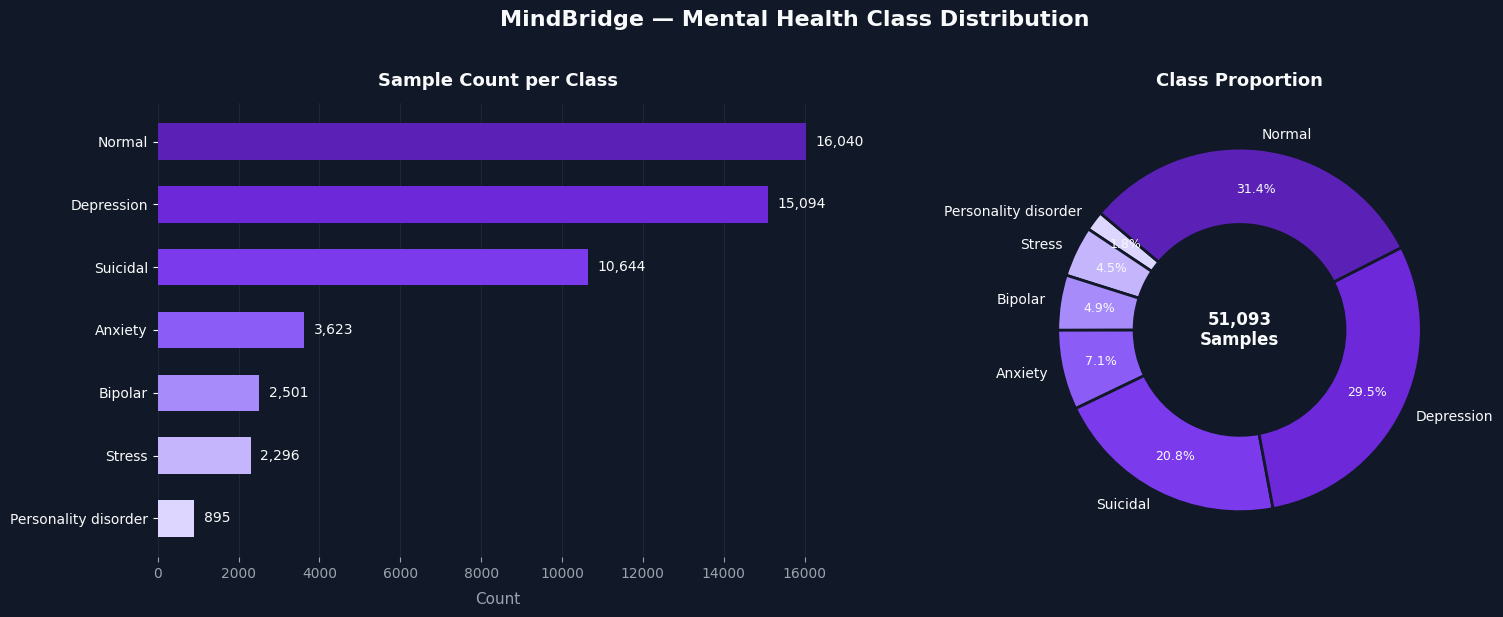

Plots Saved!


In [ ]:
class_counts = df['status'].value_counts().sort_values(ascending=True)

# MindBridge Theme
BG = '#111827'
CARD = '#1f2937'
PRIMARY = '#8b5cf6'
ACCENT = '#a78bfa'
TEXT_MAIN = '#f9fafb'
TEXT_SUB = '#9ca3af'
GRID = '#374151'

# Purple-only palette (same tone system)
COLORS = [
    '#ddd6fe',
    '#c4b5fd',
    '#a78bfa',
    '#8b5cf6',
    '#7c3aed',
    '#6d28d9',
    '#5b21b6'
]

colors = COLORS[-len(class_counts):]


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)

fig.suptitle(
    'MindBridge: Mental Health Class Distribution',
    fontsize=16,
    fontweight='bold',
    color=TEXT_MAIN,
    y=1.02
)

ax1 = axes[0]
ax1.set_facecolor(BG)

bars = ax1.barh(
    class_counts.index,
    class_counts.values,
    color=colors,
    height=0.58,
    edgecolor='none'
)

offset = class_counts.max() * 0.015

for bar, val in zip(bars, class_counts.values):
    ax1.text(
        val + offset,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}',
        va='center',
        ha='left',
        fontsize=10,
        color=TEXT_MAIN,
        fontweight='medium'
    )

ax1.set_title(
    'Sample Count per Class',
    color=TEXT_MAIN,
    fontsize=13,
    fontweight='bold',
    pad=12
)

ax1.set_xlabel('Count', color=TEXT_SUB, fontsize=11, labelpad=8)
ax1.tick_params(axis='x', colors=TEXT_SUB)
ax1.tick_params(axis='y', colors=TEXT_MAIN)

for spine in ax1.spines.values():
    spine.set_visible(False)

ax1.xaxis.grid(True, linestyle='-', linewidth=0.6, color=GRID, alpha=0.45)
ax1.set_axisbelow(True)


ax2 = axes[1]
ax2.set_facecolor(BG)

wedges, texts, autotexts = ax2.pie(
    class_counts.values,
    labels=class_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.78,
    labeldistance=1.08,
    wedgeprops={
        'width': 0.42,
        'edgecolor': BG,
        'linewidth': 2
    },
    textprops={
        'color': TEXT_MAIN,
        'fontsize': 10
    }
)

for text in texts:
    text.set_color(TEXT_MAIN)
    text.set_fontsize(10)

for autotext in autotexts:
    autotext.set_color(TEXT_MAIN)
    autotext.set_fontsize(9)
    autotext.set_fontweight('medium')

ax2.text(
    0, 0,
    f"{class_counts.sum():,}\nSamples",
    ha='center',
    va='center',
    fontsize=12,
    color=TEXT_MAIN,
    fontweight='bold'
)

ax2.set_title(
    'Class Proportion',
    color=TEXT_MAIN,
    fontsize=13,
    fontweight='bold',
    pad=12
)


plt.tight_layout()

plt.savefig(
    'results/plots/class_distribution.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=BG
)

plt.show()

print("Plots Saved!")

## Text Length Analysis

In [25]:
# Data
classes = sorted(df['status'].unique())
mean_words = df['word_count'].mean()
max_words = df['word_count'].max()
min_words = df['word_count'].min()


fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor(BG)

fig.suptitle(
    'MindBridge: Text Length Distribution',
    fontsize=16,
    fontweight='bold',
    color=TEXT_MAIN,
    y=1.02
)


ax1 = axes[0]
ax1.set_facecolor(BG)

ax1.hist(
    df['word_count'],
    bins=60,
    color=PRIMARY,
    alpha=0.82,
    edgecolor='none'
)

ax1.axvline(
    mean_words,
    color=ACCENT,
    linewidth=2,
    linestyle='--',
    label=f'Mean: {mean_words:.0f} words'
)

ax1.set_title(
    'Overall Word Count Distribution',
    color=TEXT_MAIN,
    fontsize=13,
    fontweight='bold',
    pad=10
)

ax1.set_xlabel('Word Count', color=TEXT_SUB, fontsize=11)
ax1.set_ylabel('Frequency', color=TEXT_SUB, fontsize=11)
ax1.tick_params(colors=TEXT_SUB)

for spine in ax1.spines.values():
    spine.set_visible(False)

ax1.grid(axis='y', linestyle='-', linewidth=0.6, color=GRID, alpha=0.45)
ax1.set_axisbelow(True)

legend1 = ax1.legend(
    facecolor=BG,
    edgecolor=GRID,
    fontsize=9
)
for text in legend1.get_texts():
    text.set_color(TEXT_MAIN)


ax2 = axes[1]
ax2.set_facecolor(BG)

for cls, color in zip(classes, COLORS[-len(classes):]):
    subset = df.loc[df['status'] == cls, 'word_count']
    ax2.hist(
        subset,
        bins=40,
        alpha=0.35,
        label=cls,
        color=color,
        edgecolor='none'
    )

ax2.set_title(
    'Word Count by Class',
    color=TEXT_MAIN,
    fontsize=13,
    fontweight='bold',
    pad=10
)

ax2.set_xlabel('Word Count', color=TEXT_SUB, fontsize=11)
ax2.set_ylabel('Frequency', color=TEXT_SUB, fontsize=11)
ax2.tick_params(colors=TEXT_SUB)

for spine in ax2.spines.values():
    spine.set_visible(False)

ax2.grid(axis='y', linestyle='-', linewidth=0.6, color=GRID, alpha=0.45)
ax2.set_axisbelow(True)

legend2 = ax2.legend(
    facecolor=BG,
    edgecolor=GRID,
    labelcolor=TEXT_MAIN,
    fontsize=8,
    title='Class'
)
legend2.get_title().set_color(TEXT_MAIN)


plt.tight_layout()

plt.savefig(
    'results/plots/text_length.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=BG
)

plt.show()

print(f"Average word count : {mean_words:.0f}")
print(f"Maximum word count : {max_words}")
print(f"Minimum word count : {min_words}")

KeyError: 'word_count'

## Top 15 Most Frequent Words per Class

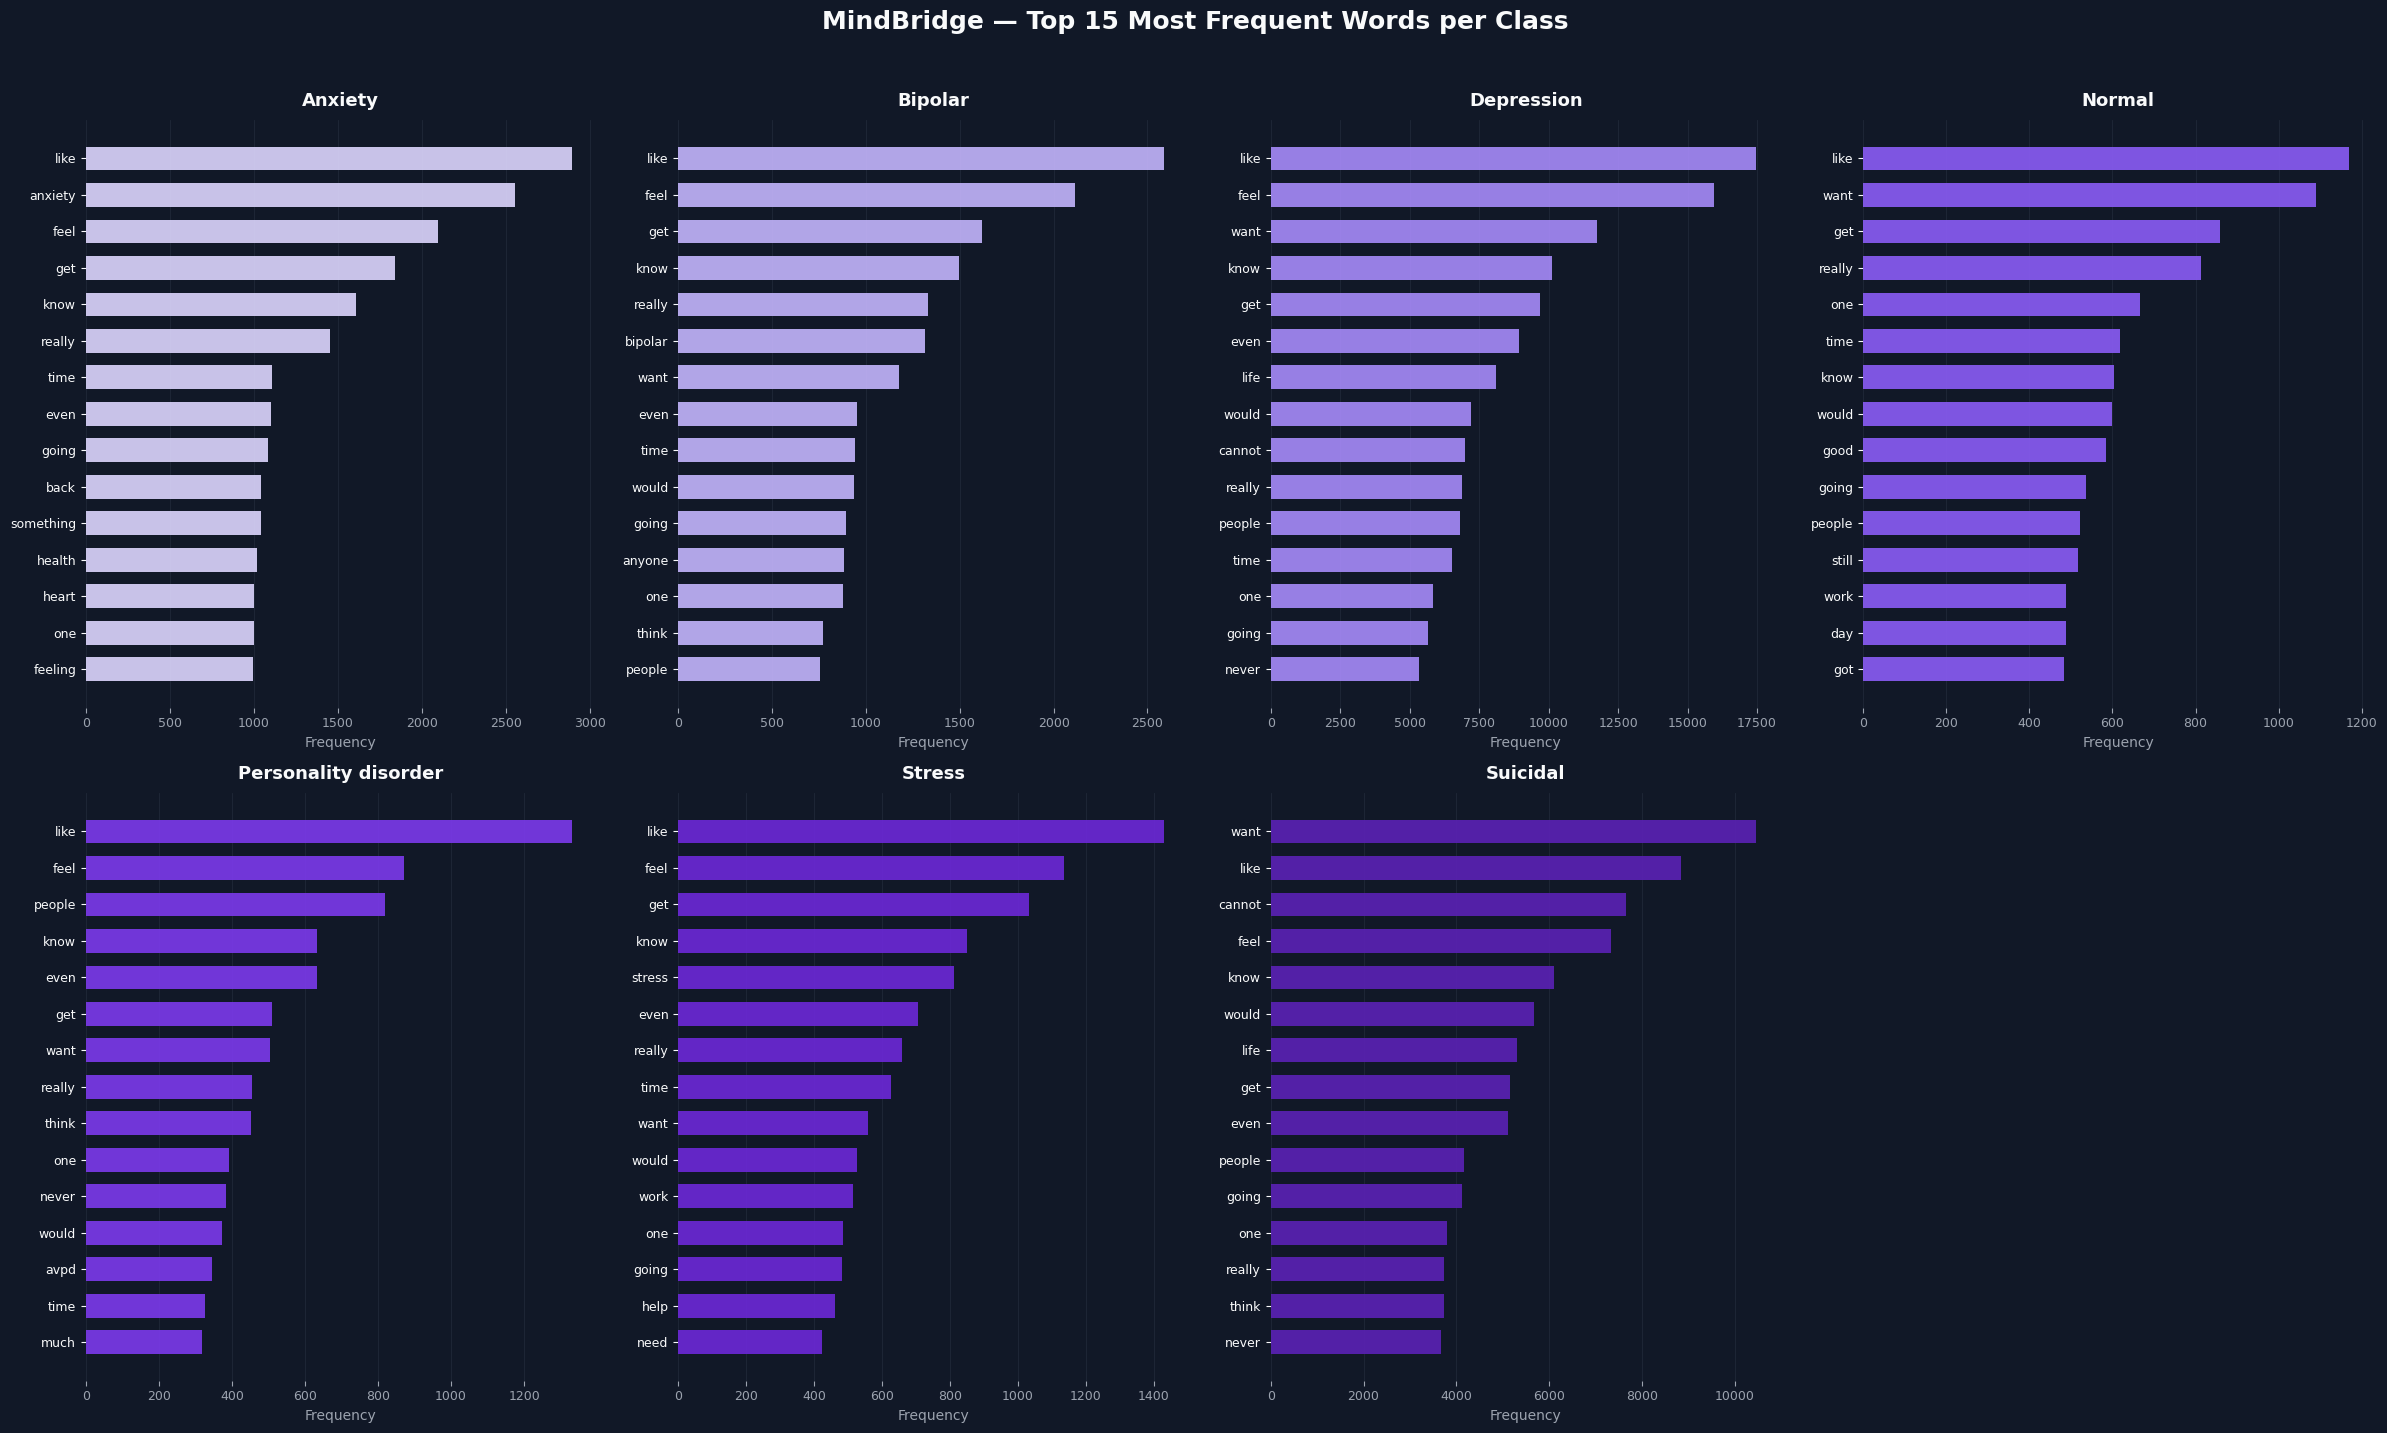

Saved: results/plots/top_words_per_class.png


In [ ]:
from collections import Counter
from nltk.corpus import stopwords
import matplotlib.pyplot as plt


# Data Prep
stop_words = set(stopwords.words('english'))
classes = sorted(df['status'].unique())

fig, axes = plt.subplots(2, 4, figsize=(24, 14))
fig.patch.set_facecolor(BG)
fig.suptitle(
    'MindBridge:Top 15 Most Frequent Words per Class',
    fontsize=18,
    fontweight='bold',
    color=TEXT_MAIN,
    y=1.02
)

axes = axes.flatten()

for i, cls in enumerate(classes):
    ax = axes[i]
    color = COLORS[i % len(COLORS)]

    texts = ' '.join(df.loc[df['status'] == cls, 'statement'].astype(str)).lower()

    words = [
        w for w in texts.split()
        if w.isalpha() and w not in stop_words and len(w) > 2
    ]

    top_words = Counter(words).most_common(15)

    if top_words:
        words_list, counts = zip(*top_words)

        ax.barh(
            list(words_list)[::-1],
            list(counts)[::-1],
            color=color,
            edgecolor='none',
            alpha=0.9,
            height=0.65
        )

    ax.set_facecolor(BG)
    ax.set_title(
        cls,
        fontsize=13,
        fontweight='bold',
        color=TEXT_MAIN,
        pad=10
    )

    ax.set_xlabel('Frequency', color=TEXT_SUB, fontsize=10)
    ax.tick_params(axis='x', colors=TEXT_SUB, labelsize=9)
    ax.tick_params(axis='y', colors=TEXT_MAIN, labelsize=9)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.xaxis.grid(True, linestyle='-', linewidth=0.6, color=GRID, alpha=0.4)
    ax.set_axisbelow(True)

for j in range(len(classes), len(axes)):
    axes[j].set_facecolor(BG)
    axes[j].axis('off')

plt.tight_layout()

plt.savefig(
    'results/plots/top_words_per_class.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=BG
)

plt.show()
print("Plot Saved!")

## Word Clouds by Class

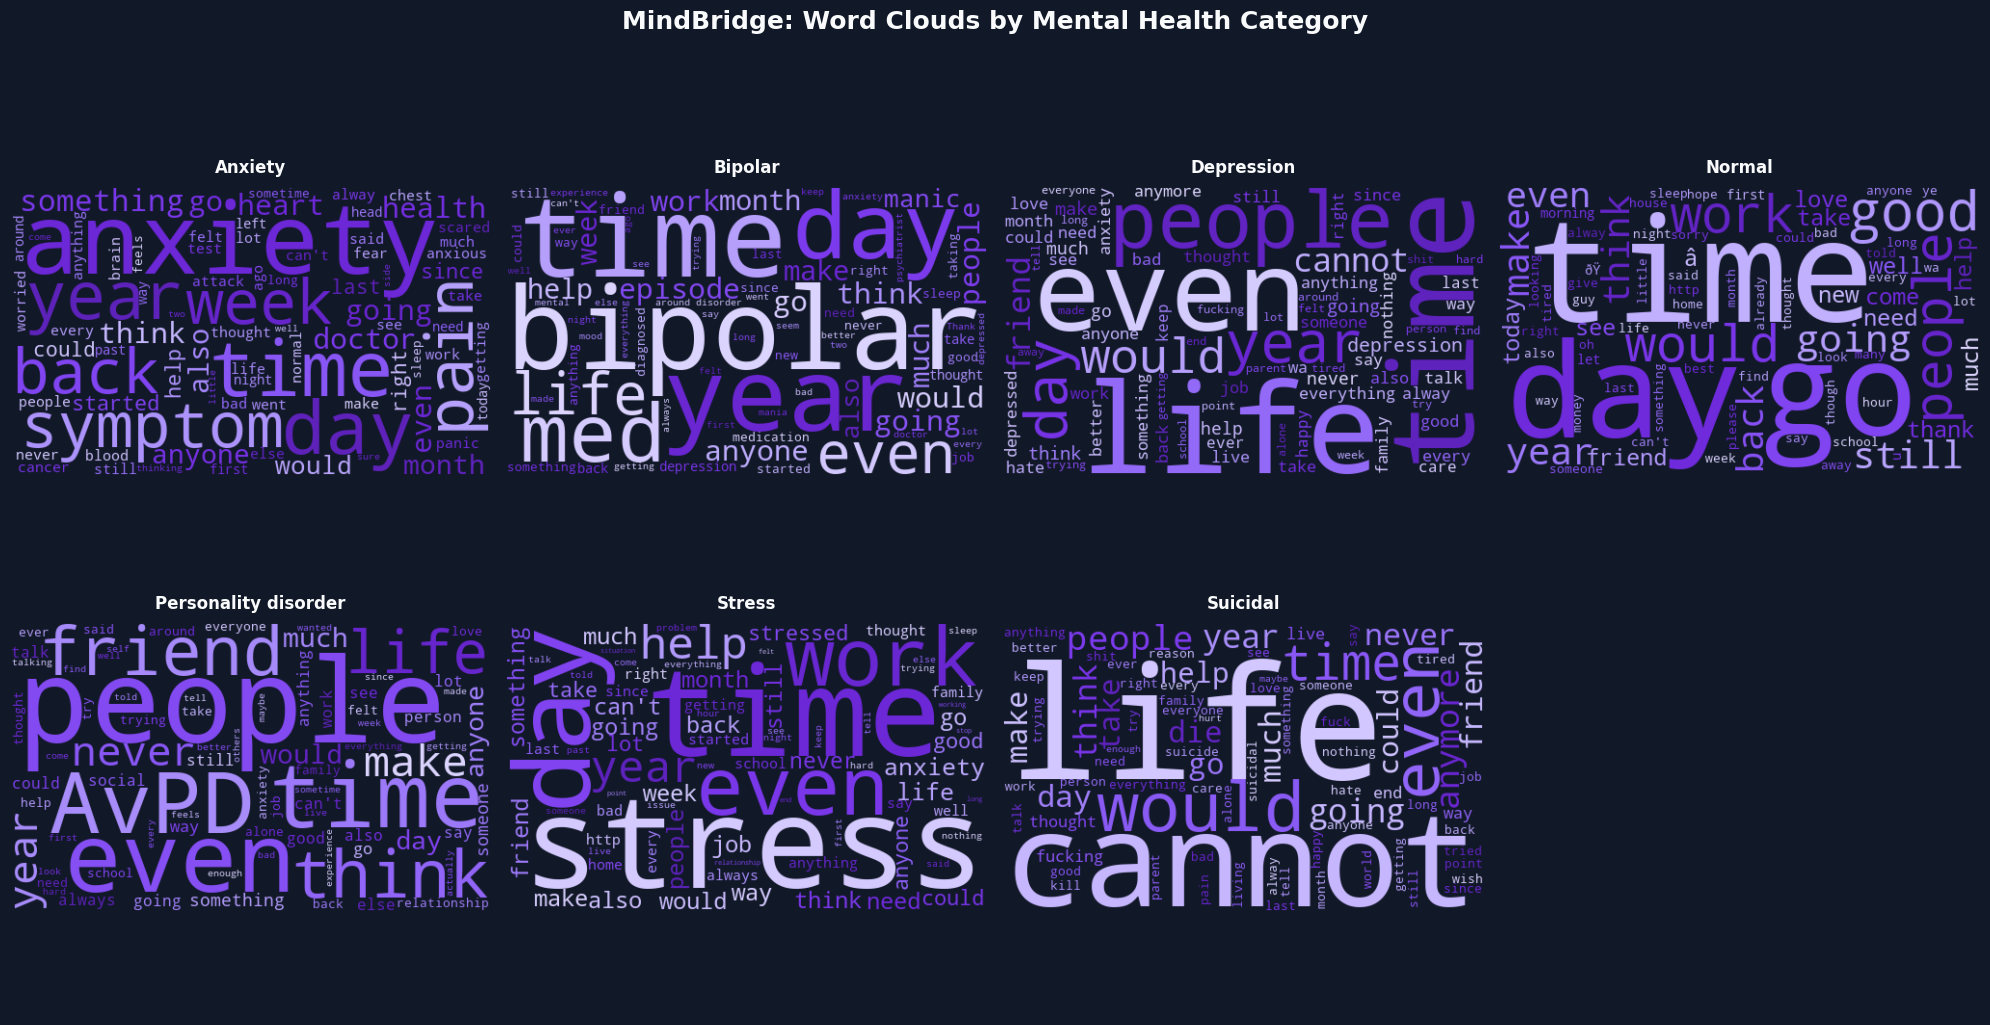

Plot Saved!


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from wordcloud import WordCloud
from nltk.corpus import stopwords


mindbridge_cmap = LinearSegmentedColormap.from_list(
    "mindbridge_purple",
    ['#ddd6fe', '#c4b5fd', '#a78bfa', '#8b5cf6', '#7c3aed', '#6d28d9', '#5b21b6']
)

# Optional: better stopword filtering
stop_words = set(stopwords.words('english'))
custom_stopwords = {
    'im', 'ive', 'dont', 'didnt', 'cant', 'couldnt',
    'wouldnt', 'really', 'get', 'got', 'one', 'like',
    'feel', 'feeling', 'know', 'want', 'thing', 'things'
}
all_stopwords = stop_words.union(custom_stopwords)

classes = sorted(df['status'].unique())

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.patch.set_facecolor(BG)
fig.suptitle(
    'MindBridge: Word Clouds by Mental Health Category',
    fontsize=18,
    fontweight='bold',
    color=TEXT_MAIN,
    y=1.02
)

axes = axes.flatten()

for i, cls in enumerate(classes):
    ax = axes[i]

    text = ' '.join(df.loc[df['status'] == cls, 'statement'].astype(str))

    wc = WordCloud(
        width=500,
        height=300,
        background_color=BG,
        colormap=mindbridge_cmap,
        max_words=80,
        stopwords=all_stopwords,
        collocations=False,
        prefer_horizontal=0.9,
        contour_width=0
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(
        cls,
        fontsize=12,
        fontweight='bold',
        color=TEXT_MAIN,
        pad=10
    )
    ax.axis('off')
    ax.set_facecolor(BG)

# Hide unused axes automatically
for j in range(len(classes), len(axes)):
    axes[j].axis('off')
    axes[j].set_facecolor(BG)

plt.tight_layout()

plt.savefig(
    'results/plots/wordclouds.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=BG
)

plt.show()
print("Plot Saved!")

## Class Imbalance Analysis

### Why This Matters??

The dataset has a **13:1 imbalance ratio** between the largest class (Normal: 30.8%) and smallest (Personality Disorder: 2.3%).

| Problem | Impact | Solution |
|---------|--------|----------|
| Majority class dominates training | Model ignores minority classes | `class_weight='balanced'` |
| Low recall on rare classes | Personality Disorder F1 will be low | SMOTE oversampling |
| Accuracy metric is misleading | 30% accuracy just by predicting Normal | Use **Weighted F1** as primary metric |

> **Decision:** We will use `class_weight='balanced'` in all models and report **Weighted F1** as the primary evaluation metric.

## Average Word Count per Class

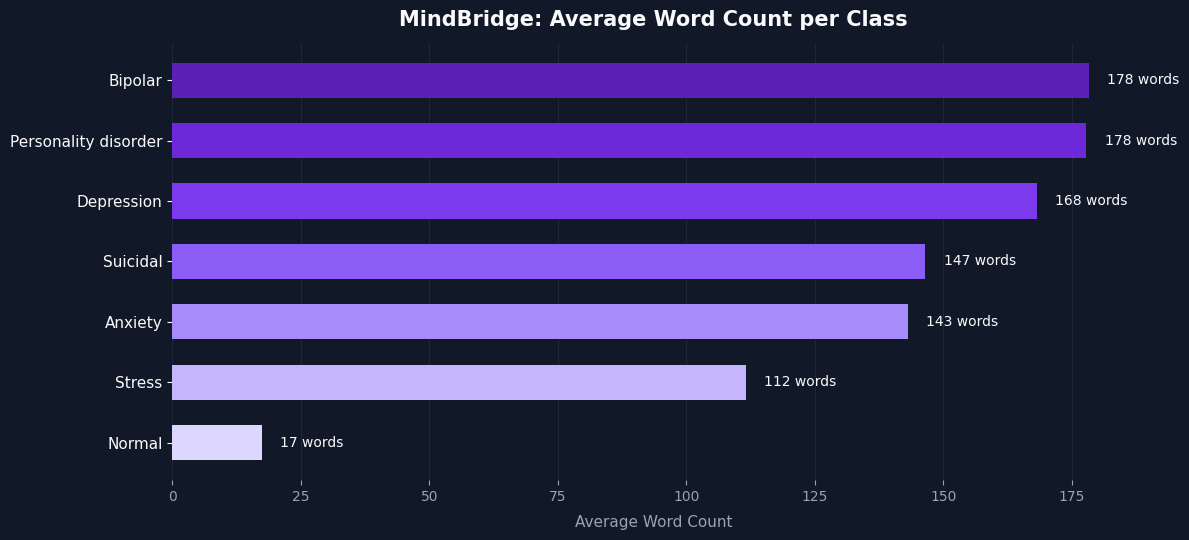

Key insight: Bipolar posts are longest (~178 words), while Normal posts are shortest (~17 words).


In [32]:

# Data
df['word_count'] = df['statement'].astype(str).str.split().str.len()
avg_words = df.groupby('status')['word_count'].mean().sort_values(ascending=True)


colors = COLORS[-len(avg_words):]


fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.barh(
    avg_words.index,
    avg_words.values,
    color=colors,
    edgecolor='none',
    height=0.58
)

offset = avg_words.max() * 0.02

for bar, val in zip(bars, avg_words.values):
    ax.text(
        val + offset,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.0f} words',
        va='center',
        ha='left',
        color=TEXT_MAIN,
        fontsize=10,
        fontweight='medium'
    )

ax.set_title(
    'MindBridge: Average Word Count per Class',
    color=TEXT_MAIN,
    fontsize=15,
    fontweight='bold',
    pad=12
)

ax.set_xlabel(
    'Average Word Count',
    color=TEXT_SUB,
    fontsize=11,
    labelpad=8
)

ax.tick_params(axis='x', colors=TEXT_SUB)
ax.tick_params(axis='y', colors=TEXT_MAIN)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.xaxis.grid(True, linestyle='-', linewidth=0.6, color=GRID, alpha=0.45)
ax.set_axisbelow(True)

for label in ax.get_yticklabels():
    label.set_fontsize(11)
    label.set_fontweight('medium')

plt.tight_layout()

plt.savefig(
    'results/plots/avg_words_per_class.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=BG
)

plt.show()

longest_class = avg_words.idxmax()
shortest_class = avg_words.idxmin()

print(
    f"Key insight: {longest_class} posts are longest "
    f"(~{avg_words.max():.0f} words), while {shortest_class} posts are shortest "
    f"(~{avg_words.min():.0f} words)."
)

## Key EDA Insights

| Finding | Detail |
|---------|--------|
| **Dataset Size** | ~51,000 samples after cleaning |
| **Class Imbalance** | Yes — Normal (30.8%) and Depression (29.2%) dominate |
| **Avg Text Length** | ~113 words per statement |
| **Shortest Texts** | Normal class (~17 words avg) |
| **Longest Texts** | Bipolar class (~178 words avg) |
| **Richest Vocabulary** | Depression and Bipolar show most diverse word usage |

### Key Challenges Identified
- Class imbalance — will use `class_weight='balanced'` in all models
- High text length variance — TF-IDF with sublinear scaling will normalize this
- Overlapping vocabulary between classes — SVM expected to handle best
